
<div style="border-radius:10px;
            border : #015a2c solid;
            background-color:#D7D9DB;
           font-size:110%;
           letter-spacing:0.5px;
            text-align: center">
​
<center><h1 style="padding: 25px 0px; color:#015a4c; font-weight: bold; font-family: Cursive">
Amit Project for Data Science Module <br><br>💡💡💡💡💡 <br><br> DEPI_BS_DS_R3  </h1></center>
<center><h3 style="padding-bottom: 25px; color:#025b2c; font-weight: bold; font-style:italic; font-family: Cursive">
Using Project: Trip data Ford go bike  </h3></center>     
​
</div>

# Part I - (Dataset Exploration for Ford GoBike)

### worked by (Omar Mohamed Fathy Dahi /2026 )

## Introduction

.

> **Let's introduce our dataset:**


======================================

.

**This data set information was produced from `Ford GoBike` System** the information in it talked about individual rides that were made in a bike-sharing system for covering San Francisco Bay area.** 

.




> ## And here are the main exploring questions 



   **==================================================**



- What is the structure of your dataset?


- What are the main interesting features in the dataset?


- What features in the dataset supported my investigation for these interesting features?




.

> ### Also here are the investigative questions classified into three types



   **================================================**
   
   


###  <a href='#011'> Univariate Exploration</a> 

- <a href='#1'> 1 ) . What is the distribution of `User type`?</a>  
- <a href='#2'> 2 ) . What is the distribution for the `bike share users on all Trips`?</a>  
- <a href='#3'> 3 ) . What is the distribution for users' `ages`?</a>  
- <a href='#4'> 4 ) . Do the users' ages have `outlier` values?</a>
- <a href='#5'> 5 ) . What is the distribution for the trip duration in `minutes`? </a>
- <a href='#6'> 6) . What is the distribution for `member_gender`? </a>
- <a href='#7'> 7) . What is the distribution for the trip duration in `Hours`?  </a>




##  <a href='#111'> Bivariate Exploration</a> 


- <a href='#8'> 8 ) . What the `average duration` of trip for the categories of `user type`? </a>
- <a href='#9'> 9 ) . How long is the duration of the trip for `each gender` in `minutes`? </a>
- <a href='#10'> 10 ) . How long is the duration of the trip for each `user_type` in `minutes`?  </a>
- <a href='#11'> 11 ) . How the user distribution depending on their `Age` and `user_type` ?</a>
- <a href='#12'>12 ). How the user distribution depending on their `Age` and `member_gender` ?  </a>


##  <a href='#1111'> Multivariate Exploration</a> 


- <a href='#13'> 13 ) . What is the Correlation between `each` variable in the dataset?</a>  
- <a href='#14'> 14 ) . What is the Correlation between `specific numeric variables` in the dataset?</a>  
- <a href='#15'> 15 ) . What is the  Correlation between `data_stat` variables in the dataset?</a>  


##  <a href='#1100'> Conclusions </a> 





# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Import Libraries</p>

In [146]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt

import seaborn as sns

%matplotlib inline

In [147]:
# Load my dataset using pandas Dataframe

df=pd.read_csv("fordgobike-tripdataFor201902.csv")


In [ ]:
# here we make overview in high-level for data shape and composition

print("The shape of the dataset is: ", df.shape,'\n')
print("the columns of the dataset are: ", df.columns,'\n')
print("the diminsion of the dataset is: ",df.ndim)


In [ ]:
## check each var  datatype 

print("the datatypes of the dataset are:\n", df.dtypes,'\n')
print("the datatypes of the dataset are:\n", df.dtypes.value_counts(),'\n')

dtype=df.dtypes
num_unique=df.nunique()
dect=pd.DataFrame({'dtype':dtype,'num_unique':num_unique}).T
print(dect)

In [ ]:
## I display 15 rows to understand the content values more 
df.head(15)


In [ ]:
# descriptive statistics for numeric variables
print("Descriptive statistics for numeric variables:\n", df.describe(),'\n')



> ### What is the structure of your dataset?





- The structure of the dataset contains  16 columns and 183416 rows.
 
 
- Most variables are str&float64 in nature , and here are **dtypes summary :**

        - str(7)
        - int(2)
        - float(7)
        



> ### What are the main interesting features in the dataset?




 **We got three main feature areas which are :**
 
 
 
 
- duration_sec
 
 
 
- bike_share_for_all_trip
 
  
 
  
- user_type




> ### What features in the dataset supported my investigation for these interesting features?



- bike_share_for_all_trip



- user_type



- member_gender


-member_birth_year




- duration_sec




##  More Exploring ideas to begin my investigation

In [ ]:
#This code for describing statistical data ideas in a more organized and readable table

print("Descriptive statistics for numeric variables in a more organized and readable table:\n", df.describe().T,'\n')

In [ ]:
# display the information about each column

print("Information about each column:\n", df.info(),'\n')
print("the member birth year contains null vales:\n", df['member_birth_year'].isnull().sum(),'\n')

## <mark>The above result show some missing values exist in some columns So let's display them </mark>

In [ ]:
#yOUR CODES
print("the number of null values in each column:\n", df.isnull().sum(),'\n')






> ## <mark>The result above shows many missing data </mark>



###  To fix this issue You will fill these values with main or median for numeric and mode for categorical

In [148]:
df['start_time'] = pd.to_datetime('2020-01-01') + pd.to_timedelta('00:' + df['start_time'].astype(str))
df['end_time'] = pd.to_datetime('2020-01-01') + pd.to_timedelta('00:' + df['end_time'].astype(str))

mask = df['end_time'] < df['start_time']
df.loc[mask, 'end_time'] += pd.Timedelta(days=1)

df['duration_sec'] = (df['end_time'] - df['start_time']).dt.total_seconds()
df['duration_minute'] = df['duration_sec'] / 60

df['date'] = df['start_time'].dt.date
df['hour'] = df['start_time'].dt.hour
df['day'] = df['start_time'].dt.day
df['day_of_week'] = df['start_time'].dt.day_name()
df['month'] = df['start_time'].dt.month
df['year'] = df['start_time'].dt.year

df['time_id'] = df['start_time'].dt.strftime('%Y%m%d%H')

In [152]:
dtype=df.dtypes
num_unique=df.nunique()
dect=pd.DataFrame({'dtype':dtype,'num_unique':num_unique}).T
dect

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,member_gender,bike_share_for_all_trip,duration_minute,date,hour,day,day_of_week,month,year,time_id
dtype,float64,datetime64[us],datetime64[us],float64,str,float64,float64,float64,str,float64,...,str,str,float64,object,int32,int32,str,int32,int32,str
num_unique,32453,35783,44640,329,329,334,335,329,329,335,...,3,2,32453,1,1,1,1,1,1,1


In [149]:

print(df.columns)
df

Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip',
       'duration_minute', 'date', 'hour', 'day', 'day_of_week', 'month',
       'year', 'time_id'],
      dtype='str')


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,member_gender,bike_share_for_all_trip,duration_minute,date,hour,day,day_of_week,month,year,time_id
0,84585.9,2020-01-01 00:32:10.100,2020-01-02 00:01:56.000,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,...,Male,No,1409.765000,2020-01-01,0,1,Wednesday,1,2020,2020010100
1,85721.3,2020-01-01 00:53:21.800,2020-01-02 00:42:03.100,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,...,NaN,No,1428.688333,2020-01-01,0,1,Wednesday,1,2020,2020010100
2,654.9,2020-01-01 00:13:13.200,2020-01-01 00:24:08.100,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,...,Male,No,10.915000,2020-01-01,0,1,Wednesday,1,2020,2020010100
3,83290.8,2020-01-01 00:54:26.000,2020-01-02 00:02:36.800,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,...,Other,No,1388.180000,2020-01-01,0,1,Wednesday,1,2020,2020010100
4,84385.6,2020-01-01 00:54:18.500,2020-01-02 00:20:44.100,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,...,Male,Yes,1406.426667,2020-01-01,0,1,Wednesday,1,2020,2020010100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183411,271.5,2020-01-01 00:00:20.600,2020-01-01 00:04:52.100,24.0,Spear St at Folsom St,37.789677,-122.390428,37.0,2nd St at Folsom St,37.785000,...,Male,No,4.525000,2020-01-01,0,1,Wednesday,1,2020,2020010100
183412,313.8,2020-01-01 00:05:34.700,2020-01-01 00:10:48.500,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,66.0,3rd St at Townsend St,37.778742,...,Male,No,5.230000,2020-01-01,0,1,Wednesday,1,2020,2020010100
183413,141.7,2020-01-01 00:06:05.500,2020-01-01 00:08:27.200,278.0,The Alameda at Bush St,37.331932,-121.904888,277.0,Morrison Ave at Julian St,37.333658,...,Male,Yes,2.361667,2020-01-01,0,1,Wednesday,1,2020,2020010100
183414,139.9,2020-01-01 00:05:34.400,2020-01-01 00:07:54.300,220.0,San Pablo Ave at MLK Jr Way,37.811351,-122.273422,216.0,San Pablo Ave at 27th St,37.817827,...,Male,No,2.331667,2020-01-01,0,1,Wednesday,1,2020,2020010100


In [153]:
df["users' age"] = df['start_time'].dt.year - df['member_birth_year']
df["users' age"] = df["users' age"].clip(upper=90)

bins = [0, 35, 55, 100]
labels = ['Young', 'Adult', 'Senior']

df['age_group'] = pd.cut(
    df["users' age"], bins=bins, labels=labels, right=True)

cat_cols = [
    'user_type',              
    'member_gender',          
    'bike_share_for_all_trip',
    'day_of_week',            
    'start_station_name',
    'end_station_name',
    'bike_id',
    'end_station_id',
    'start_station_id',
    'time_id',
    'age_group'
]


for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

num_cols = [
    'duration_sec',
    'duration_minute',
    "users' age",              
    'start_station_latitude',
    'start_station_longitude',
    'end_station_latitude',
    'end_station_longitude',    
    'hour',
    'day',
    'month',
    'year'
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Categorical Columns:", df.select_dtypes(include=['category', 'object']).columns.tolist())
print("Numerical Columns:", df.select_dtypes(include=['number']).columns.tolist())

Categorical Columns: ['start_station_id', 'start_station_name', 'end_station_id', 'end_station_name', 'bike_id', 'user_type', 'member_gender', 'bike_share_for_all_trip', 'date', 'day_of_week', 'time_id', 'age_group']
Numerical Columns: ['duration_sec', 'start_station_latitude', 'start_station_longitude', 'end_station_latitude', 'end_station_longitude', 'member_birth_year', 'duration_minute', 'hour', 'day', 'month', 'year', "users' age"]


In [ ]:
dtype=df.dtypes
num_unique=df.nunique()
dect=pd.DataFrame({'dtype':dtype,'num_unique':num_unique}).T
print(dect)

           duration_sec      start_time        end_time start_station_id  \
dtype           float64  datetime64[us]  datetime64[us]         category   
num_unique        32453           35783           44640              329   

           start_station_name start_station_latitude start_station_longitude  \
dtype                category                float64                 float64   
num_unique                329                    334                     335   

           end_station_id end_station_name end_station_latitude  ...  \
dtype            category         category              float64  ...   
num_unique            329              329                  335  ...   

           duration_minute    date   hour    day day_of_week  month   year  \
dtype              float64  object  int32  int32    category  int32  int32   
num_unique           32453       1      1      1           1      1      1   

             time_id users' age age_group  
dtype       category    float64  c

In [157]:
null=df.isna().sum()
ratio=((null/df.shape[0])*100).round(3)
dtype=df.dtypes
pd.DataFrame({"dtype":dtype,"null":null , "ratio(%)":ratio}).T
print(ratio)


duration_sec               0.000
start_time                 0.000
end_time                   0.000
start_station_id           0.107
start_station_name         0.107
start_station_latitude     0.000
start_station_longitude    0.000
end_station_id             0.107
end_station_name           0.107
end_station_latitude       0.000
end_station_longitude      0.000
bike_id                    0.000
user_type                  0.000
member_birth_year          4.506
member_gender              4.506
bike_share_for_all_trip    0.000
duration_minute            0.000
date                       0.000
hour                       0.000
day                        0.000
day_of_week                0.000
month                      0.000
year                       0.000
time_id                    0.000
users' age                 4.506
age_group                  4.506
dtype: float64


In [158]:
cols_to_drop=["start_station_id","start_station_name","end_station_id","end_station_name"]
df.dropna(subset=cols_to_drop,axis=0,inplace=True)


In [159]:
null=df.isna().sum()
ratio=((null/df.shape[0])*100).round(3)
dtype=df.dtypes
pd.DataFrame({"dtype":dtype,"null":null , "ratio(%)":ratio}).T


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,duration_minute,date,hour,day,day_of_week,month,year,time_id,users' age,age_group
dtype,float64,datetime64[us],datetime64[us],category,category,float64,float64,category,category,float64,...,float64,object,int32,int32,category,int32,int32,category,float64,category
null,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,8263,8263
ratio(%),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.51,4.51


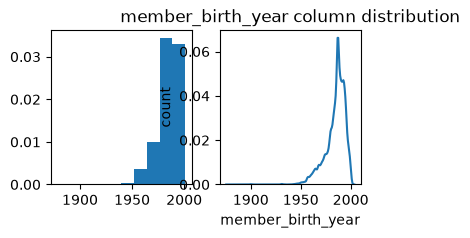

In [162]:
plt.figure(figsize=(4,2))
plt.subplot(1,2,1)
plt.hist(df["member_birth_year"],density=True)
plt.subplot(1,2,2)
sns.kdeplot(df["member_birth_year"])
plt.title("member_birth_year column distribution")
plt.xlabel("member_birth_year")
plt.ylabel("count")
plt.show()

In [160]:
df["member_gender"]=df["member_gender"].fillna(value=df["member_gender"].mode()[0])
df["member_birth_year"]=df["member_birth_year"].fillna(value=df['member_birth_year'].median())
df["users' age"]=df["users' age"].fillna(value=df["users' age"].median())


In [161]:
bins = [0, 35, 55, 100]
labels = ['Young', 'Adult', 'Senior']

df['age_group'] = pd.cut(
    df["users' age"], bins=bins, labels=labels, right=True)

In [164]:
#check the Nulls 
null=df.isna().sum()
ratio=((null/df.shape[0])*100).round(3)
dtype=df.dtypes
pd.DataFrame({"dtype":dtype,"null":null , "ratio(%)":ratio}).T
print(ratio)

duration_sec               0.0
start_time                 0.0
end_time                   0.0
start_station_id           0.0
start_station_name         0.0
start_station_latitude     0.0
start_station_longitude    0.0
end_station_id             0.0
end_station_name           0.0
end_station_latitude       0.0
end_station_longitude      0.0
bike_id                    0.0
user_type                  0.0
member_birth_year          0.0
member_gender              0.0
bike_share_for_all_trip    0.0
duration_minute            0.0
date                       0.0
hour                       0.0
day                        0.0
day_of_week                0.0
month                      0.0
year                       0.0
time_id                    0.0
users' age                 0.0
age_group                  0.0
dtype: float64


### **And with a proper category for other (member gender)**

In [ ]:
##  still got a missing value in the member_gender, so let's explore this column more 

print(df.member_gender.head(15))

In [ ]:
# fill  dataset with missing values.
    


In [ ]:
# print(gbf.member_gender.head(15))

In [ ]:
## check my result above 

#check the Nulls 
null=df.isna().sum()
ratio=((null/df.shape[0])*100).round(3)
dtype=df.dtypes
pd.DataFrame({"dtype":dtype,"null":null , "ratio(%)":ratio}).T


> ## <mark>The result above shows that we deal with all missing data </mark>

### Now let's check duplicate value

In [165]:
##  check duplicate in dataset

df.duplicated().sum()


np.int64(4)

In [166]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True)


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,duration_minute,date,hour,day,day_of_week,month,year,time_id,users' age,age_group
0,84585.9,2020-01-01 00:32:10.100,2020-01-02 00:01:56.000,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,...,1409.765000,2020-01-01,0,1,Wednesday,1,2020,2020010100,36.0,Adult
1,85721.3,2020-01-01 00:53:21.800,2020-01-02 00:42:03.100,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,...,1428.688333,2020-01-01,0,1,Wednesday,1,2020,2020010100,33.0,Young
2,654.9,2020-01-01 00:13:13.200,2020-01-01 00:24:08.100,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,...,10.915000,2020-01-01,0,1,Wednesday,1,2020,2020010100,48.0,Adult
3,83290.8,2020-01-01 00:54:26.000,2020-01-02 00:02:36.800,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,...,1388.180000,2020-01-01,0,1,Wednesday,1,2020,2020010100,31.0,Young
4,84385.6,2020-01-01 00:54:18.500,2020-01-02 00:20:44.100,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,...,1406.426667,2020-01-01,0,1,Wednesday,1,2020,2020010100,46.0,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183210,480.3,2020-01-01 00:04:49.700,2020-01-01 00:12:50.000,27.0,Beale St at Harrison St,37.788059,-122.391865,324.0,Union Square (Powell St at Post St),37.788300,...,8.005000,2020-01-01,0,1,Wednesday,1,2020,2020010100,24.0,Young
183211,313.8,2020-01-01 00:05:34.700,2020-01-01 00:10:48.500,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,66.0,3rd St at Townsend St,37.778742,...,5.230000,2020-01-01,0,1,Wednesday,1,2020,2020010100,36.0,Adult
183212,141.7,2020-01-01 00:06:05.500,2020-01-01 00:08:27.200,278.0,The Alameda at Bush St,37.331932,-121.904888,277.0,Morrison Ave at Julian St,37.333658,...,2.361667,2020-01-01,0,1,Wednesday,1,2020,2020010100,30.0,Young
183213,139.9,2020-01-01 00:05:34.400,2020-01-01 00:07:54.300,220.0,San Pablo Ave at MLK Jr Way,37.811351,-122.273422,216.0,San Pablo Ave at 27th St,37.817827,...,2.331667,2020-01-01,0,1,Wednesday,1,2020,2020010100,32.0,Young


In [167]:
df.duplicated().sum()

np.int64(0)

> ##If Not significant duplicated , so won't clean it 


### Now let's check the category columns to make more cleaning dataset 

In [ ]:
### check the category columns that included object
cate_cols=df.select_dtypes("category").columns
print(cate_cols)

 > ## From all previous results above I found  :
 
 
 
 **=========================================================**
 
 

> 1 ) **unique Value** as in ((`member_gender`)) : Not significant , so won't clean it



> 2 ) **Incorrect data type** as in (( `user_type` &&	`member_gender`)) :  significant change , so I need to clean it.


> 3 ) **Good factor** for marketing work as in ((`member_birth_year`)) : so I need to clean it.

In [ ]:
##  step  2 ) Incorrect data type as in (( `user_type` &&	`member_gender`)) :  significant change , so  need to clean it.



In [ ]:
## check your work 



In [ ]:
df["users' age"].dtype


In [ ]:
## check your work 

df.head(10)

In [ ]:
## change the new column age data type from float to int
df["users' age"].dtype



In [ ]:
## create a function to know the average users ages

def avg(df:pd.DataFrame,col:str)->float:
    """Calculates the arithmetic mean of a specified numerical column in a
  pandas DataFrame.

  Args:
      df (pd.DataFrame): The DataFrame containing the target dataset.
      col (str): The name of the numerical column to calculate the mean for.

  Returns:
      float: The calculated mean of the specified column, ignoring missing
        (NaN) values.
  """

    return float(df[col].mean().__round__(4))


In [ ]:
avg_age=avg(df,"users' age")
print(avg_age)

In [ ]:
## another important factor to offer  marketing services is the trip duration time 

## need to change the time from second to minute to be more usable

df.head(10)
#df["duration_minute"]=df['duration_sec']/60

In [ ]:
## I need to change the time from second to Houre  to be more usable

#df["duration_houre"]=df['duration_sec']/(60*60)

In [168]:
## check your work 
df.head(10)

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,duration_minute,date,hour,day,day_of_week,month,year,time_id,users' age,age_group
0,84585.9,2020-01-01 00:32:10.100,2020-01-02 00:01:56.000,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,...,1409.765000,2020-01-01,0,1,Wednesday,1,2020,2020010100,36.0,Adult
1,85721.3,2020-01-01 00:53:21.800,2020-01-02 00:42:03.100,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,...,1428.688333,2020-01-01,0,1,Wednesday,1,2020,2020010100,33.0,Young
2,654.9,2020-01-01 00:13:13.200,2020-01-01 00:24:08.100,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,...,10.915000,2020-01-01,0,1,Wednesday,1,2020,2020010100,48.0,Adult
3,83290.8,2020-01-01 00:54:26.000,2020-01-02 00:02:36.800,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,...,1388.180000,2020-01-01,0,1,Wednesday,1,2020,2020010100,31.0,Young
4,84385.6,2020-01-01 00:54:18.500,2020-01-02 00:20:44.100,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,...,1406.426667,2020-01-01,0,1,Wednesday,1,2020,2020010100,46.0,Adult
5,84593.2,2020-01-01 00:49:58.600,2020-01-02 00:19:51.800,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,...,1409.886667,2020-01-01,0,1,Wednesday,1,2020,2020010100,61.0,Senior
6,83947.5,2020-01-01 00:55:35.100,2020-01-02 00:14:42.600,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,...,1399.125000,2020-01-01,0,1,Wednesday,1,2020,2020010100,37.0,Adult
7,84416.0,2020-01-01 00:41:06.800,2020-01-02 00:08:02.800,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,...,1406.933333,2020-01-01,0,1,Wednesday,1,2020,2020010100,31.0,Young
8,84370.9,2020-01-01 00:41:48.800,2020-01-02 00:07:59.700,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,...,1406.181667,2020-01-01,0,1,Wednesday,1,2020,2020010100,32.0,Young
9,83849.3,2020-01-01 00:49:47.700,2020-01-02 00:07:17.000,19.0,Post St at Kearny St,37.788975,-122.403452,121.0,Mission Playground,37.759210,...,1397.488333,2020-01-01,0,1,Wednesday,1,2020,2020010100,28.0,Young


In [169]:
df['trip_id'] = range(1, len(df) + 1)

In [170]:
dim_time = df[[
    'time_id',
    'date',
    'hour',
    'day',
    'day_of_week',
    'month',
    'year',
]].drop_duplicates(subset=['time_id'])

start_stations = df[[
    'start_station_id',
    'start_station_name',
    'start_station_latitude',
    'start_station_longitude',
]].rename(
    columns={
        'start_station_id': 'station_id',
        'start_station_name': 'station_name',
        'start_station_latitude': 'latitude',
        'start_station_longitude': 'longitude',
    }
)

end_stations = df[[
    'end_station_id',
    'end_station_name',
    'end_station_latitude',
    'end_station_longitude',
]].rename(
    columns={
        'end_station_id': 'station_id',
        'end_station_name': 'station_name',
        'end_station_latitude': 'latitude',
        'end_station_longitude': 'longitude',
    }
)

dim_station = (
    pd.concat([start_stations, end_stations])
    .drop_duplicates(subset=['station_id'])
    .dropna(subset=['station_id'])
)

dim_user = df[[
    'member_birth_year',
    "users' age",
    'member_gender',
    'user_type',
]].drop_duplicates().reset_index(drop=True)
dim_user['user_id'] = range(1, len(dim_user) + 1)
dim_user.rename(
    columns={'member_birth_year': 'birth_year', "users' age": 'age',"member_gender":'gender'},
    inplace=True,
)

df = df.merge(
    dim_user,
    left_on=[
        'member_birth_year',
        "users' age",
        'member_gender',
        'user_type',
    ],
    right_on=['birth_year', 'age', 'gender', 'user_type'],
    how='left',
)

In [171]:
fact_trips = df[[
    'trip_id',
    'start_time',
    'end_time',
    'duration_sec',
    'bike_id',
    'start_station_id',
    'end_station_id',
    'user_id',
    'time_id',
]]

fact_trips.to_csv('fact_trips.csv', index=False)
dim_time.to_csv('dim_time.csv', index=False)
dim_station.to_csv('dim_station.csv', index=False)
dim_user.to_csv('dim_user.csv', index=False)

In [174]:
dim_station = dim_station.dropna(subset=['station_id']).copy()

dim_station['station_id'] = dim_station['station_id'].astype(int)

dim_station = dim_station.drop_duplicates(subset=['station_id'])

dim_station.to_csv('dim_station.csv', index=False)

In [182]:

dim_user['age'] = dim_user['age'].astype(int)
dim_user['birth_year'] = dim_user['birth_year'].astype(int)
dim_user = dim_user[['user_id', 'birth_year', 'age', 'gender', 'user_type']]
dim_user.to_csv('dim_user.csv', index=False)


In [196]:
cols=['user_id','start_station_id',"end_station_id"]
fact_trips[cols]=fact_trips[cols].astype(int)
fact_trips.to_csv('fact_trips.csv', index=False)


# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Univariate Exploration</p>
# <a id="011"> Univariate Exploration</a>



> In this section, investigate distributions of individual variables. If
you see unusual points or outliers, take a deeper look to clean things up
and prepare yourself to look at relationships between variables.




# <a id="1"> 1 ) . What is the distribution for User type?</a>

In [ ]:
num_cols=df.select_dtypes('number').columns
plt.figure(figsize=(10,5))
for i , col in enumerate(num_cols):
    plt.subplot(3,3,i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} boxplot")
    plt.subplots_adjust(hspace=.8,wspace=.3)
plt.show()

In [ ]:
## I will import seaborn library to support me in making visualizations 

import seaborn as sns

x=df[df["users' age"]>90]["users' age"].values
df["users' age"]=df["users' age"].replace(x,90)

y=df[df["duration_minute"]>1440]["duration_minute"].values
df["duration_minute"]=df["duration_minute"].replace(y,1440)



> ### <mark>Your analsys and exploration here </mark>


In [ ]:
plt.figure(figsize = (10,3), dpi = 200)
plt.subplot(1,2,1)
sns.countplot(data=df, x='user_type')
plt.subplot(1,2,2)
unique=df["user_type"].value_counts()
count=unique.values
categories=unique.index
plt.pie(count,labels=categories, autopct="%1.1d%%")
plt.xlabel('User distribution')
plt.ylabel('Frequency')
plt.title("Represent the user's distribution depending on being a part of the Trips Program")
plt.subplots_adjust(hspace=.1,wspace=.1)
plt.show()

# <a id="2"> 2 ) What is the distribution for the bike share users on all Trips?</a>

> ### <mark>Your analsys and exploration here </mark>

In [ ]:
plt.figure(figsize = (10,3), dpi = 200)
plt.subplot(1,2,1)
sns.countplot(data=df, x='bike_share_for_all_trip')
plt.subplot(1,2,2)
unique=df["bike_share_for_all_trip"].value_counts()
count=unique.values
categories=unique.index
plt.pie(count,labels=categories, autopct="%1.1d%%")
plt.xlabel('User distribution')
plt.ylabel('Frequency')
plt.title("Represent the user's distribution depending on being a part of the Trips Program")
plt.subplots_adjust(hspace=.1,wspace=.1)
plt.show()

# <a id="3"> 3 ) What is the distribution for users' ages? </a>

> ### <mark>Your analsys and exploration here </mark>

In [ ]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.hist(df["users' age"], edgecolor="black")
plt.subplot(1,2,2)
sns.kdeplot(df["users' age"])
plt.subplots_adjust(hspace=.8,wspace=.3)
plt.show()


# <a id="4">  4 ) . Do the users' ages have outlier values?</a>


> ### <mark>Your analsys and exploration here </mark>

In [ ]:
plt.figure(figsize=(8,2))
sns.boxplot(df["users' age"], orient="h")
plt.show()

# <a id="5">  5 ) . What is the distribution for the trip duration in minutes? </a>

In [ ]:
## Review the statistic for trip duration in minutes

des=df["duration_minute"].describe()
pd.DataFrame(des.T)


In [ ]:
# Make visualization to easy get insight

plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
sns.histplot(df["duration_minute"], edgecolor="black",bins=30)
plt.xlim(0, 100)
plt.subplot(1,2,2)
sns.kdeplot(df["duration_minute"])
plt.xlim(0, 100)
plt.subplots_adjust(hspace=.8,wspace=.3)
plt.show()

> ### <mark>Your analsys and exploration here </mark>


# <a id="6"> 6 ) . What is the distribution for member_gender?</a>

In [ ]:
# Make visualization to easy get insight

plt.figure(figsize = (10,3), dpi = 200)
plt.subplot(1,2,1)
sns.countplot(data=df, x='member_gender')
plt.subplot(1,2,2)
unique=df["member_gender"].value_counts()
count=unique.values
categories=unique.index
plt.pie(count,labels=categories, autopct="%1.1d%%")
plt.xlabel('User distribution')
plt.ylabel('Frequency')
plt.title("Represent the user's distribution depending on being a part of the Trips Program")
plt.subplots_adjust(hspace=.1,wspace=.1)
plt.show()

> ### <mark>Your analsys and exploration here </mark>

# <a id="7">    7 )  . What is the distribution for the trip duration in Hours?  </a>

In [ ]:
# Make visualization to easy get insight

plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.hist(df["duration_minute"]/60, edgecolor="black", bins=30)
plt.subplot(1,2,2)
sns.kdeplot(df["duration_minute"]/60)
plt.xlabel('duration_hours')
plt.subplots_adjust(hspace=.8,wspace=.3)
plt.show()

> ### <mark>Your analsys and exploration here </mark>

### The variables distribution:


> The distribution of duration present that most of the trips were less than 30 minutes ( we can notice that from the minutes and the hour charts )


> And the Age distribution is ( left Skewed ) as most users age are  22 - 39


> Most users are subscribers, not Customers and  Males as shown in the charts above.



### Were there any interesting and outliers 


- We got Age outliers for for more than 100 .



- The distribution of duration was strange where the minutes and the hour charts were 30 minutes or less.

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Bivariate Exploration</p>
# <a id="111"> Bivariate Exploration</a>

Now let's investigate relationships between pairs of variables in our data.

In [ ]:
df.columns

# <a id="8"> 8) . What the average duration of trip for the categories of user type?</a>

In [ ]:
# Distribution of Age by user types

plt.figure(figsize=(5,2))
sns.barplot(x=df["user_type"],y=df["duration_minute"])
plt.show()

# Make visualization to easy get insight


> ### <mark>Your analsys and exploration here </mark>

# <a id="9">    9 ) . How long is the duration of the trip for each gender in minutes?  </a>

In [ ]:
# Make visualization to easy get insight

# ------------------------Duration distribution by member gender

plt.figure(figsize=(5,5))
sns.barplot(x=df["member_gender"],y=df["duration_minute"])
plt.show()


# Make visualization to easy get insight


> ### <mark>Your analsys and exploration here </mark>

# <a id="10 "> 10 ) . How long is the duration of the trip for each user_type in minutes?  </a>

In [ ]:

# Make visualization to easy get insight

plt.figure(figsize=(4,2))
sns.barplot(x=df["user_type"],y=df["duration_minute"])
plt.show()


> ### <mark>Your analsys and exploration here </mark>

# <a id="11">  11 ) . How the user distribution depending on their Age and user_type ? </a>

In [ ]:

# Make visualization to easy get insight

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="users' age", hue='user_type', kde=True, element="step")
plt.title("Age Distribution by User Type")
plt.show()

> ### <mark>Your analsys and exploration here </mark>

#  <a id="12"> 12 ). How the user distribution depending on their Age and member_gender ?</a>

In [ ]:
# Make visualization to easy get insight
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="users' age", hue='member_gender', kde=True, element="step")
plt.title("Age Distribution by User Type")
plt.show()

> ### <mark>Your analsys and exploration here </mark>

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> 1-the subscribers' duration less than the customers                        
> 2-the male's duration is smallest and the other's duration is biggest 



### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> the subscribers' age bigger than customers' age

# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Multivariate Exploration</p>
# <a id="1111"> Multivariate Exploration </a>

> Create plots of three or more variables to investigate your data even
further. Make sure that your investigations are justified, and follow from
your work in the previous sections.

In [ ]:
## check your work 



# <a id="13">  13 ) . What is the  Correlation between each variable in the dataset?</a>

In [ ]:
# Make visualization to easy get insight
corr=df.corr(numeric_only=True)
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True , cmap="coolwarm",fmt=".2f")
plt.show()





> ### <mark>Your analsys and exploration here </mark>

Example usage
- There is `no Correlation` for any variable with time ( `duration sec /minutes/hours`)



# <a id="14"> 14 )  .  What is the  Correlation between `specific numeric variables` in the dataset?</a>


In [ ]:
# Make visualization to easy get insight

selected_cols = ["duration_minute", "users' age"]
sns.pairplot(df[selected_cols], kind="reg")
plt.show()

In [ ]:
corr = df[["duration_minute", "users' age"]].corr()
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True , cmap="coolwarm",fmt=".2f")
plt.show()


> ### <mark>Your analsys and exploration here </mark>

Example usage
- There is `no Correlation` for any variable with time ( `duration sec /minutes`)




- 




- 




# <a id="15">  15 ) What is the  Correlation between data_stat variables in the dataset?</a>


In [ ]:

"""""This time I will use heatmap  to explain how Correlation between data_stat variables

in the dataset in more clear and specific percentage"""

# Make visualization to easy get insight

num_df = df.select_dtypes('number')
corr = num_df.corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()



> ### <mark>The above charts show how Correlation between specific numeric variables in the dataset using heatmap plots  </mark>



**Actually the `heat map`  display the above ideas in clear percentages**



- There is `no Correlation` for any variable with time ( `duration sec /minutes`)




- There is a `negative  Correlation` between  member_birth_year  and age which normal.




- There is `no significant Correlation` for any variable with `bike_id `



# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Conclusions</p>
# <a id="1100"> Conclusions </a>

#example
- Most users were Male.


- Most users were subscribers

- most users' age between 22 and 39

- most customers' duration are high



## limitation 
example
- We got missing data which we fix some of them .

- we got dublicates data which we fix some of them.


In [ ]:
df.to_csv("processed_data.csv", index=False)